<a href="https://colab.research.google.com/github/sadeesacs/FYP/blob/main/Growth_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import zipfile
import shutil
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/Plantify_ML ")
ZIP_PATH = BASE_DIR / "Month1.zip"

EXTRACT_DIR = Path("/content/Month1")
DATA_DIR = EXTRACT_DIR / "Data2"

if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)
print("Data directory exists:", DATA_DIR.exists())

Extracted to: /content/Month1
Data directory exists: True


In [ ]:
from datetime import datetime
from collections import Counter
import pandas as pd

date_folders = []

for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        try:
            date_obj = datetime.strptime(folder.name, "%Y-%m-%d").date()
            image_count = len(list(folder.glob("*.png")))
            date_folders.append({
                "date": date_obj,
                "folder": folder,
                "image_count": image_count
            })
        except ValueError:
            pass

date_df = pd.DataFrame(date_folders).sort_values("date").reset_index(drop=True)

display(date_df)

print("Number of date folders:", len(date_df))
print("Total PNG images:", date_df["image_count"].sum())
print("First date:", date_df["date"].min())
print("Last date:", date_df["date"].max())

,date,folder,image_count
0,2024-05-21,/content/Month1/Data2/2024-05-21,372
1,2024-05-22,/content/Month1/Data2/2024-05-22,481
2,2024-05-25,/content/Month1/Data2/2024-05-25,493
3,2024-05-26,/content/Month1/Data2/2024-05-26,2587
4,2024-05-28,/content/Month1/Data2/2024-05-28,1360
5,2024-05-29,/content/Month1/Data2/2024-05-29,1394
6,2024-05-30,/content/Month1/Data2/2024-05-30,965
7,2024-05-31,/content/Month1/Data2/2024-05-31,1597
8,2024-06-01,/content/Month1/Data2/2024-06-01,1983
9,2024-06-02,/content/Month1/Data2/2024-06-02,1017


Number of date folders: 16
Total PNG images: 26483
First date: 2024-05-21
Last date: 2024-06-10


In [ ]:
import math

first_date = date_df["date"].min()
last_date = date_df["date"].max()

date_df["day_number"] = date_df["date"].apply(lambda d: (d - first_date).days + 1)

max_day = date_df["day_number"].max()

early_end = math.ceil(max_day / 3)
middle_end = math.ceil((max_day * 2) / 3)

def assign_growth_stage(day):
    if day <= early_end:
        return "early_growth"
    elif day <= middle_end:
        return "middle_growth"
    else:
        return "late_growth"

date_df["label"] = date_df["day_number"].apply(assign_growth_stage)

display(date_df[["date", "day_number", "image_count", "label"]])

print("Class distribution by image count:")
display(date_df.groupby("label")["image_count"].sum())

,date,day_number,image_count,label
0,2024-05-21,1,372,early_growth
1,2024-05-22,2,481,early_growth
2,2024-05-25,5,493,early_growth
3,2024-05-26,6,2587,early_growth
4,2024-05-28,8,1360,middle_growth
5,2024-05-29,9,1394,middle_growth
6,2024-05-30,10,965,middle_growth
7,2024-05-31,11,1597,middle_growth
8,2024-06-01,12,1983,middle_growth
9,2024-06-02,13,1017,middle_growth


Class distribution by image count:


,image_count
label,
early_growth,3933
late_growth,9851
middle_growth,12699


In [ ]:
import random
import shutil

OUTPUT_DIR = Path("/content/plantify_growth_dataset")

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

splits = ["train", "val", "test"]
labels = ["early_growth", "middle_growth", "late_growth"]

for split in splits:
    for label in labels:
        (OUTPUT_DIR / split / label).mkdir(parents=True, exist_ok=True)

random.seed(42)

split_records = []

for label in labels:
    label_dates = date_df[date_df["label"] == label]["date"].tolist()
    random.shuffle(label_dates)

    n = len(label_dates)
    n_train = max(1, int(n * 0.7))
    n_val = max(1, int(n * 0.15))

    train_dates = label_dates[:n_train]
    val_dates = label_dates[n_train:n_train + n_val]
    test_dates = label_dates[n_train + n_val:]

    if len(test_dates) == 0 and len(val_dates) > 1:
        test_dates.append(val_dates.pop())

    split_map = {
        "train": train_dates,
        "val": val_dates,
        "test": test_dates
    }

    for split, dates in split_map.items():
        for date_value in dates:
            folder_row = date_df[date_df["date"] == date_value].iloc[0]
            source_folder = folder_row["folder"]

            for img_path in source_folder.glob("*.png"):
                new_name = f"{date_value}_{img_path.name}"
                target_path = OUTPUT_DIR / split / label / new_name
                shutil.copy2(img_path, target_path)

            split_records.append({
                "date": date_value,
                "label": label,
                "split": split,
                "image_count": folder_row["image_count"]
            })

split_df = pd.DataFrame(split_records).sort_values(["split", "label", "date"])

display(split_df)

print("Final image counts:")
for split in splits:
    print("\n", split.upper())
    for label in labels:
        count = len(list((OUTPUT_DIR / split / label).glob("*.png")))
        print(label, ":", count)

,date,label,split,image_count
3,2024-05-21,early_growth,test,372
15,2024-06-10,late_growth,test,893
10,2024-05-29,middle_growth,test,1394
9,2024-06-03,middle_growth,test,4383
1,2024-05-22,early_growth,train,481
0,2024-05-25,early_growth,train,493
13,2024-06-04,late_growth,train,1374
11,2024-06-05,late_growth,train,3202
12,2024-06-07,late_growth,train,3641
7,2024-05-28,middle_growth,train,1360


Final image counts:

 TRAIN
early_growth : 974
middle_growth : 5905
late_growth : 8217

 VAL
early_growth : 2587
middle_growth : 1017
late_growth : 741

 TEST
early_growth : 372
middle_growth : 5777
late_growth : 893


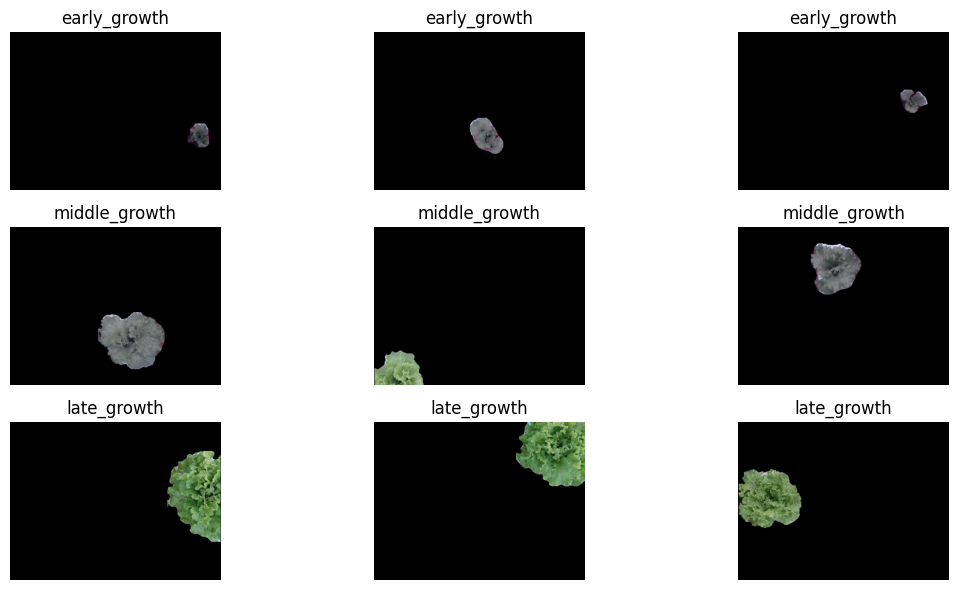

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(12, 6))

plot_index = 1

for label in labels:
    image_paths = list((OUTPUT_DIR / "train" / label).glob("*.png"))
    sample_paths = random.sample(image_paths, min(3, len(image_paths)))

    for img_path in sample_paths:
        img = Image.open(img_path).convert("RGB")

        plt.subplot(3, 3, plot_index)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 15096 files belonging to 3 classes.
Found 4345 files belonging to 3 classes.
Found 7042 files belonging to 3 classes.
Class names: ['early_growth', 'late_growth', 'middle_growth']
Number of classes: 3


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

In [ ]:
from tensorflow.keras import layers, models
import tensorflow as tf

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)   # fixed line

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
class_counts = {}

for class_name in class_names:
    class_counts[class_name] = len(list((OUTPUT_DIR / "train" / class_name).glob("*.png")))

print("Class counts:", class_counts)

total_images = sum(class_counts.values())

class_weight = {
    i: total_images / (num_classes * class_counts[class_names[i]])
    for i in range(num_classes)
}

print("Class weights:", class_weight)

Class counts: {'early_growth': 974, 'late_growth': 8217, 'middle_growth': 5905}
Class weights: {0: 5.166324435318275, 1: 0.6123889497383473, 2: 0.8521591871295512}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

CHECKPOINT_PATH = "/content/drive/MyDrive/Plantify_ML/best_plantify_growth_model.keras"

callbacks = [
    ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/10
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.4643 - loss: 0.9513
Epoch 1: val_accuracy improved from None to 0.60092, saving model to /content/drive/MyDrive/Plantify_ML/best_plantify_growth_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Plantify_ML/best_plantify_growth_model.keras
472/472 ━━━━━━━━━━━━━━━━━━━━ 78s 142ms/step - accuracy: 0.5654 - loss: 0.8006 - val_accuracy: 0.6009 - val_loss: 0.8095 - learning_rate: 1.0000e-04
Epoch 2/10
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6785 - loss: 0.5953
Epoch 2: val_accuracy did not improve from 0.60092
472/472 ━━━━━━━━━━━━━━━━━━━━ 55s 117ms/step - accuracy: 0.6815 - loss: 0.5860 - val_accuracy: 0.5915 - val_loss: 0.9361 - learning_rate: 1.0000e-04
Epoch 3/10
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7011 - loss: 0.5494
Epoch 3: val_accuracy did not improve from 0.60092

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
472/472 ━━━━━━━━━━━━━━━

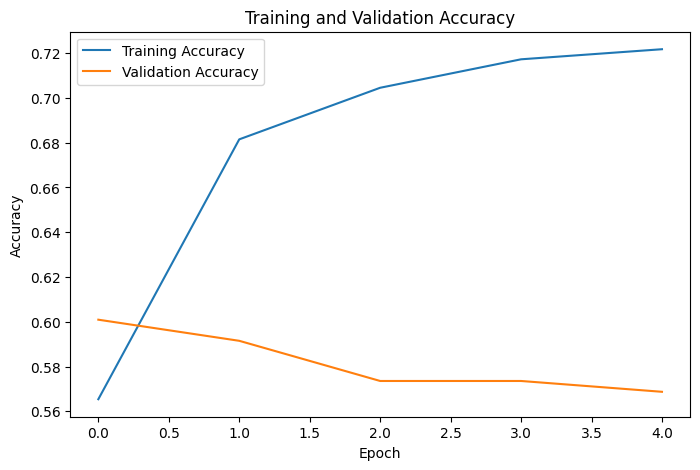

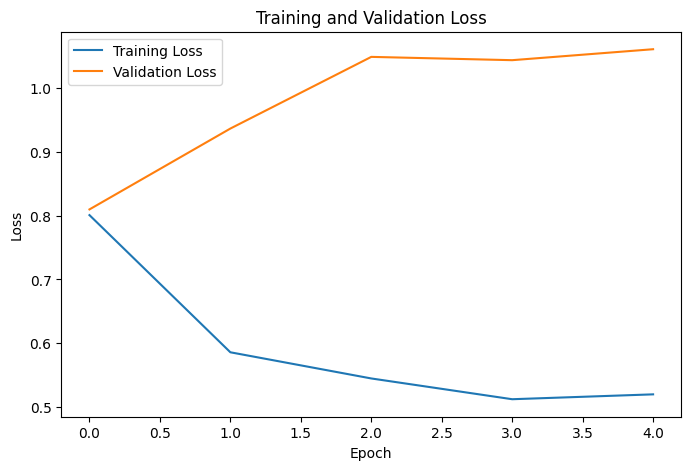

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
base_model.trainable = True

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

FINE_TUNE_EPOCHS = 5

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.6205 - loss: 0.7110
Epoch 1: val_accuracy improved from 0.60092 to 0.71162, saving model to /content/drive/MyDrive/Plantify_ML/best_plantify_growth_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Plantify_ML/best_plantify_growth_model.keras
472/472 ━━━━━━━━━━━━━━━━━━━━ 89s 160ms/step - accuracy: 0.6759 - loss: 0.6138 - val_accuracy: 0.7116 - val_loss: 0.5888 - learning_rate: 1.0000e-05
Epoch 2/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.7402 - loss: 0.4782
Epoch 2: val_accuracy did not improve from 0.71162
472/472 ━━━━━━━━━━━━━━━━━━━━ 64s 136ms/step - accuracy: 0.7413 - loss: 0.4724 - val_accuracy: 0.6955 - val_loss: 0.5800 - learning_rate: 1.0000e-05
Epoch 3/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7568 - loss: 0.4489
Epoch 3: val_accuracy did not improve from 0.71162
472/472 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - accuracy: 0.7568 - loss: 0.4478 - val_accuracy: 0.64

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

221/221 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - accuracy: 0.5866 - loss: 0.9382
Test loss: 0.9381714463233948
Test accuracy: 0.5866231322288513


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

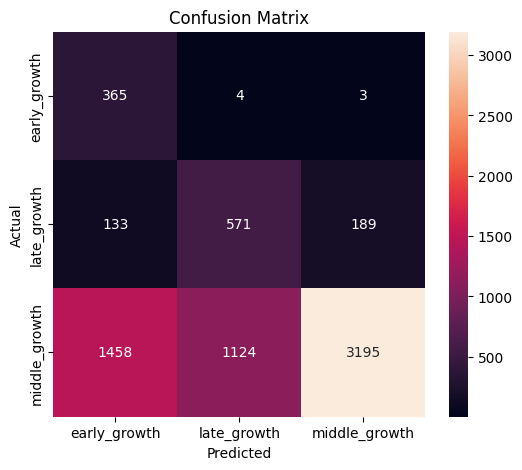

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels_batch in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels_batch.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import json

FINAL_MODEL_PATH = "/content/drive/MyDrive/Plantify_ML/plantify_mobilenetv2_growth_model.keras"
LABELS_PATH = "/content/drive/MyDrive/Plantify_ML/class_names.json"

model.save(FINAL_MODEL_PATH)

with open(LABELS_PATH, "w") as f:
    json.dump(class_names, f)

print("Saved model to:", FINAL_MODEL_PATH)
print("Saved labels to:", LABELS_PATH)

Saved model to: /content/drive/MyDrive/Plantify_ML/plantify_mobilenetv2_growth_model.keras
Saved labels to: /content/drive/MyDrive/Plantify_ML/class_names.json


In [ ]:
history_df = pd.DataFrame(history.history)

if "history_fine" in globals():
    fine_df = pd.DataFrame(history_fine.history)
    history_df = pd.concat([history_df, fine_df], ignore_index=True)

HISTORY_PATH = "/content/drive/MyDrive/Plantify_ML/training_history.csv"
history_df.to_csv(HISTORY_PATH, index=False)

print("Saved training history to:", HISTORY_PATH)

Saved training history to: /content/drive/MyDrive/Plantify_ML/training_history.csv


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step


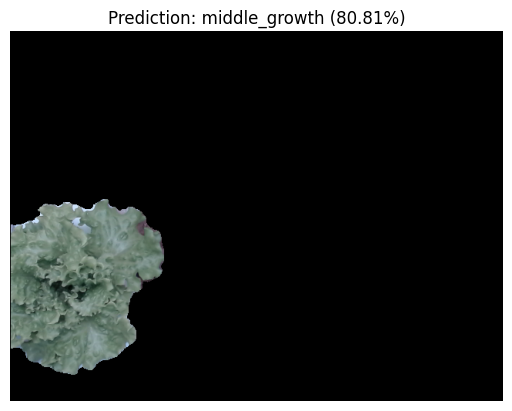

Image path: /content/plantify_growth_dataset/test/middle_growth/2024-06-03_cam1=14-48-48_segment_1.png
Predicted class: middle_growth
Confidence: 80.80976605415344
All predictions:
early_growth : 3.1 %
late_growth : 16.09 %
middle_growth : 80.81 %


In [ ]:
from PIL import Image
import numpy as np
import random
import matplotlib.pyplot as plt

test_image_paths = list((OUTPUT_DIR / "test").rglob("*.png"))
sample_path = random.choice(test_image_paths)

img = Image.open(sample_path).convert("RGB")
img_resized = img.resize(IMG_SIZE)

img_array = tf.keras.utils.img_to_array(img_resized)
img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)[0]

predicted_index = np.argmax(predictions)
predicted_class = class_names[predicted_index]
confidence = float(predictions[predicted_index]) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
plt.show()

print("Image path:", sample_path)
print("Predicted class:", predicted_class)
print("Confidence:", confidence)
print("All predictions:")

for class_name, score in zip(class_names, predictions):
    print(class_name, ":", round(float(score) * 100, 2), "%")